# Benchmark principal: clasificación multiclase TLM:UAV

Este es el ejecutable principal del estudio. Compara un baseline lineal, TabNet, TabTransformer, FT-Transformer y SAINT supervisado bajo exactamente los mismos vuelos externos, vistas de variables y semillas.

La evidencia de reconstrucción está en [00_dataset_audit.ipynb](00_dataset_audit.ipynb) y la preparación detallada en [01_multiclass_classification.ipynb](01_multiclass_classification.ipynb). Ambos son complementarios: este cuaderno puede ejecutarse desde un kernel nuevo sin ejecutarlos antes.

## 1. Protocolo experimental

La unidad externa es el vuelo inferido, nunca la fila. Cada dirección leave-one-flight-out usa un vuelo completo para desarrollo y el otro exclusivamente para evaluación. Dentro de desarrollo, una validación por episodios con purga temporal selecciona la época; después se recrea el modelo y se reajusta con todo desarrollo durante un número fijo de épocas.

`sensor_core` restringe la entrada a señales físicas instantáneas. `full_diagnostic` conserva contexto operacional y sirve como ablación de sensibilidad a proxies, no como vista libre de leakage.

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data import (
    FlightSplitConfig,
    prepare_lofo_data,
    reconstruct_and_align,
)
from src.evaluation import (
    computational_cost_table,
    descriptive_comparison_table,
    flightwise_comparison_table,
    per_class_frame,
    plot_flightwise_metric,
    plot_mean_confusion_matrices,
    validate_benchmark_results,
)
from src.training import (
    make_benchmark_config,
    resolve_device,
    run_multiclass_benchmark,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
pd.set_option("display.max_columns", 40)

## 2. Configuración central

El perfil `smoke` ejecuta las veinte combinaciones con una semilla y dos épocas para verificar integración; sus métricas no sustentan un ranking científico. El perfil `study` usa tres semillas, hasta 60 épocas y early stopping. Cambiar de perfil crea otro directorio y evita mezclar resultados.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "data.py").is_file():
    raise FileNotFoundError("Ejecute el notebook desde la raíz de TLM")

PROFILE = "study"  # Use "smoke" solo para comprobar integración.
FORCE_RETRAIN = False

config = make_benchmark_config(PROJECT_ROOT, profile=PROFILE)
resolved_device = resolve_device(config.device)
{
    "profile": config.profile,
    "device": resolved_device,
    "models": config.model_names,
    "views": config.feature_views,
    "seeds": config.seeds,
    "max_epochs": config.max_epochs,
    "patience": config.patience,
    "output": config.output_dir.relative_to(PROJECT_ROOT),
}

{'profile': 'study',
 'device': 'cuda',
 'models': ('logistic_regression',
  'tabnet',
  'tab_transformer',
  'ft_transformer',
  'saint_supervised'),
 'views': ('sensor_core', 'full_diagnostic'),
 'seeds': (17, 42, 73),
 'max_epochs': 60,
 'patience': 10,
 'output': WindowsPath('results/benchmark/study')}

## 3. Datos congelados

La reconstrucción asigna `flight_id` sin consultar labels, alinea GPS y IMU de forma causal sobre el reloj VIBE y adopta VIBE como referencia explícita del target. Las aserciones siguientes impiden continuar si cambia la fuente, falla un fold o un preprocesador usa filas externas.

In [3]:
reconstructed, aligned = reconstruct_and_align(PROJECT_ROOT)
folds, prepared_folds = prepare_lofo_data(
    aligned,
    FlightSplitConfig(),
)

assert bool(aligned.checks.all())
assert all(all(fold.report["checks"].values()) for fold in folds)
assert all(bool(item.checks.all()) for item in prepared_folds)

protocol_rows = []
for fold in folds:
    protocol_rows.append(
        {
            "fold": fold.name,
            "inner_train": len(fold.inner_train_row_ids),
            "validation": len(fold.valid_row_ids),
            "purged": len(fold.purged_row_ids),
            "external_test": len(fold.test_row_ids),
            "minimum_gap_s": (
                fold.report["minimum_train_valid_gap_seconds"]
            ),
        }
    )
display(pd.DataFrame(protocol_rows))

,fold,inner_train,validation,purged,external_test,minimum_gap_s
0,develop_f0_test_f1,3132,975,791,3736,5.000499
1,develop_f1_test_f0,2198,744,794,4898,5.000499


## 4. Modelos

- **Regresión logística:** referencia lineal sobre la misma representación preprocesada.
- **TabNet:** máscaras secuenciales y embeddings categóricos; sus máscaras no implican causalidad.
- **TabTransformer:** contextualiza categorías y une después las variables continuas. En `sensor_core` se reduce a su rama numérica.
- **FT-Transformer:** convierte cada variable en un token antes de aplicar atención.
- **SAINT supervisado:** usa embeddings continuos por columna y atención entre columnas. La atención entre filas está desactivada para que cada predicción sea inductiva e independiente del batch.

In [4]:
results = run_multiclass_benchmark(
    aligned,
    prepared_folds,
    config,
    force=FORCE_RETRAIN,
)
print(f"Ejecuciones completas: {len(results)}")

2026-07-20 18:36:02,330 | INFO | Reusing completed run logistic_regression__sensor_core__develop_f0_test_f1__seed_17__b7c0784f05
2026-07-20 18:36:02,334 | INFO | Reusing completed run logistic_regression__sensor_core__develop_f0_test_f1__seed_42__07bd190ba9
2026-07-20 18:36:02,338 | INFO | Reusing completed run logistic_regression__sensor_core__develop_f0_test_f1__seed_73__430fb275e2
2026-07-20 18:36:02,341 | INFO | Reusing completed run logistic_regression__full_diagnostic__develop_f0_test_f1__seed_17__0a03dbae04
2026-07-20 18:36:02,345 | INFO | Reusing completed run logistic_regression__full_diagnostic__develop_f0_test_f1__seed_42__f11de277cf
2026-07-20 18:36:02,349 | INFO | Reusing completed run logistic_regression__full_diagnostic__develop_f0_test_f1__seed_73__5e69acc8ca
2026-07-20 18:36:02,353 | INFO | Reusing completed run logistic_regression__sensor_core__develop_f1_test_f0__seed_17__4ed70986f9
2026-07-20 18:36:02,357 | INFO | Reusing completed run logistic_regression__sensor_co

Ejecuciones completas: 60


## 5. Integridad de resultados

La evaluación vuelve a leer las predicciones persistidas, verifica probabilidades y row IDs, recalcula métricas y comprueba cada checkpoint. Un mensaje de éxito no sustituye estas aserciones.

In [5]:
result_checks = validate_benchmark_results(
    results,
    prepared_folds,
    PROJECT_ROOT,
    expected_models=config.model_names,
    expected_views=config.feature_views,
    expected_seeds=config.seeds,
)
display(result_checks.to_frame())

,passed
run_grid_is_complete,True
run_keys_are_unique,True
all_artifacts_exist,True
all_probabilities_are_valid,True
persisted_rows_match_external_folds,True
persisted_metrics_recompute_exactly,True
all_checkpoints_reload_within_tolerance,True
only_primary_and_secondary_regions_exist,True


## 6. Comparación

El ranking usa todas las filas del vuelo externo. Los dos vuelos se muestran por separado y el peor vuelo se conserva: promediarlo todo ocultaría el shift entre direcciones. La exclusión de bordes de transición queda como sensibilidad secundaria y nunca determina el ranking.

In [6]:
comparison = descriptive_comparison_table(results)
flightwise = flightwise_comparison_table(results)
costs = computational_cost_table(results)

display(comparison.round(4))
display(flightwise.round(4))
display(costs.round(3))

,view_name,model_name,balanced_accuracy_mean,f1_macro_mean,f1_macro_worst_flight,mcc_mean,roc_auc_ovr_macro_mean,pr_auc_macro_mean,maximum_seed_std
0,full_diagnostic,tab_transformer,0.9141,0.8871,0.8734,0.8493,0.9857,0.9485,0.0062
1,full_diagnostic,ft_transformer,0.8789,0.8453,0.7904,0.7923,0.9528,0.8908,0.0602
2,full_diagnostic,tabnet,0.8502,0.8349,0.7669,0.7812,0.9649,0.8890,0.0349
3,full_diagnostic,logistic_regression,0.8522,0.8141,0.7509,0.7523,0.9718,0.9219,0.0000
4,full_diagnostic,saint_supervised,0.8084,0.7858,0.6826,0.7102,0.9412,0.8544,0.0231
5,sensor_core,saint_supervised,0.6835,0.6198,0.5772,0.4888,0.8627,0.6750,0.0475
6,sensor_core,ft_transformer,0.6796,0.6190,0.5953,0.4998,0.8612,0.6714,0.0325
7,sensor_core,logistic_regression,0.6467,0.5712,0.4802,0.4634,0.8348,0.5991,0.0000
8,sensor_core,tabnet,0.6579,0.5654,0.5609,0.4527,0.8351,0.6030,0.0572
9,sensor_core,tab_transformer,0.6349,0.5494,0.4116,0.4559,0.8521,0.6200,0.0515


,view_name,model_name,test_flight,balanced_accuracy_mean,f1_macro_mean,mcc_mean,roc_auc_ovr_macro_mean,pr_auc_macro_mean,balanced_accuracy_seed_std,f1_macro_seed_std,mcc_seed_std,roc_auc_ovr_macro_seed_std,pr_auc_macro_seed_std
0,full_diagnostic,tab_transformer,0,0.9389,0.8734,0.8326,0.9903,0.9557,0.0056,0.0062,0.0081,0.0006,0.0001
1,full_diagnostic,ft_transformer,0,0.8601,0.7904,0.7174,0.9614,0.8854,0.0453,0.0602,0.0760,0.0045,0.0302
2,full_diagnostic,tabnet,0,0.8047,0.7669,0.6878,0.9569,0.8629,0.0570,0.0349,0.0268,0.0128,0.0501
3,full_diagnostic,logistic_regression,0,0.8530,0.7509,0.6706,0.9703,0.9190,0.0000,0.0000,0.0000,0.0000,0.0000
4,full_diagnostic,saint_supervised,0,0.7354,0.6826,0.5690,0.9200,0.7875,0.0080,0.0231,0.0122,0.0192,0.0309
5,full_diagnostic,tabnet,1,0.8957,0.9030,0.8746,0.9730,0.9150,0.0052,0.0075,0.0111,0.0094,0.0189
6,full_diagnostic,tab_transformer,1,0.8894,0.9008,0.8660,0.9812,0.9413,0.0089,0.0058,0.0097,0.0008,0.0015
7,full_diagnostic,ft_transformer,1,0.8978,0.9002,0.8672,0.9441,0.8963,0.0019,0.0047,0.0064,0.0058,0.0146
8,full_diagnostic,saint_supervised,1,0.8813,0.8889,0.8513,0.9623,0.9213,0.0228,0.0113,0.0191,0.0134,0.0081
9,full_diagnostic,logistic_regression,1,0.8514,0.8772,0.8339,0.9733,0.9249,0.0000,0.0000,0.0000,0.0000,0.0000


,view_name,model_name,tuning_seconds_mean,refit_seconds_mean,inference_seconds_mean,best_epoch_mean,parameter_count_mean
0,full_diagnostic,logistic_regression,0.041,0.059,0.001,0.000,195.0
1,full_diagnostic,ft_transformer,3.860,2.755,0.058,9.833,27877.0
2,full_diagnostic,tab_transformer,3.791,3.421,0.012,14.333,36069.0
3,full_diagnostic,saint_supervised,12.577,10.183,0.089,11.833,43781.0
4,full_diagnostic,tabnet,16.753,11.032,0.169,8.500,30296.0
5,sensor_core,logistic_regression,0.039,0.069,0.001,0.000,80.0
6,sensor_core,tab_transformer,1.216,0.970,0.003,10.833,3269.0
7,sensor_core,ft_transformer,2.231,1.172,0.025,5.167,26693.0
8,sensor_core,saint_supervised,8.421,6.449,0.049,10.000,34885.0
9,sensor_core,tabnet,16.682,11.267,0.170,9.167,27268.0


## 7. Diagnóstico visual y por clase

F1 macro da el mismo peso a cada tipo de falla. Las matrices normalizadas permiten comprobar si una media aceptable oculta el colapso de una clase minoritaria. Las barras de error representan variación entre semillas, no vuelos independientes.

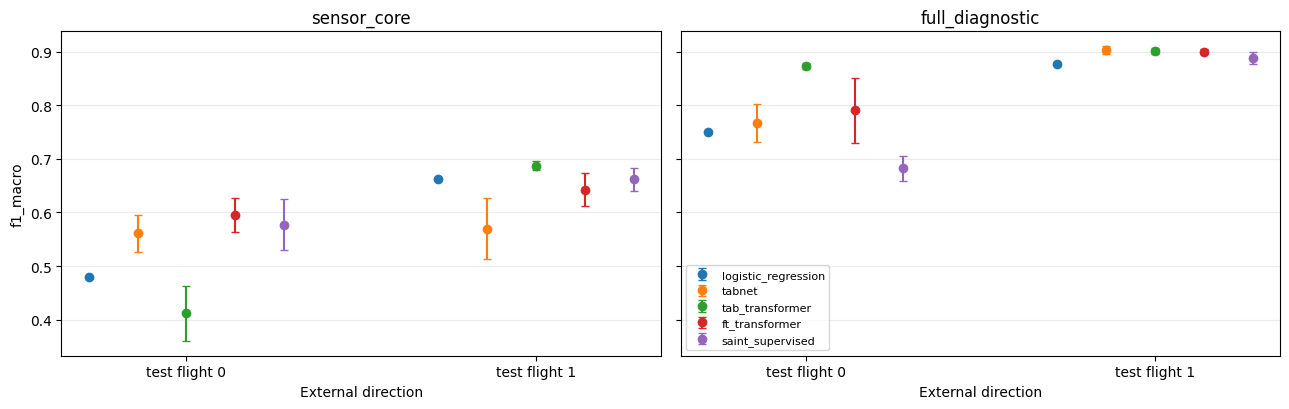

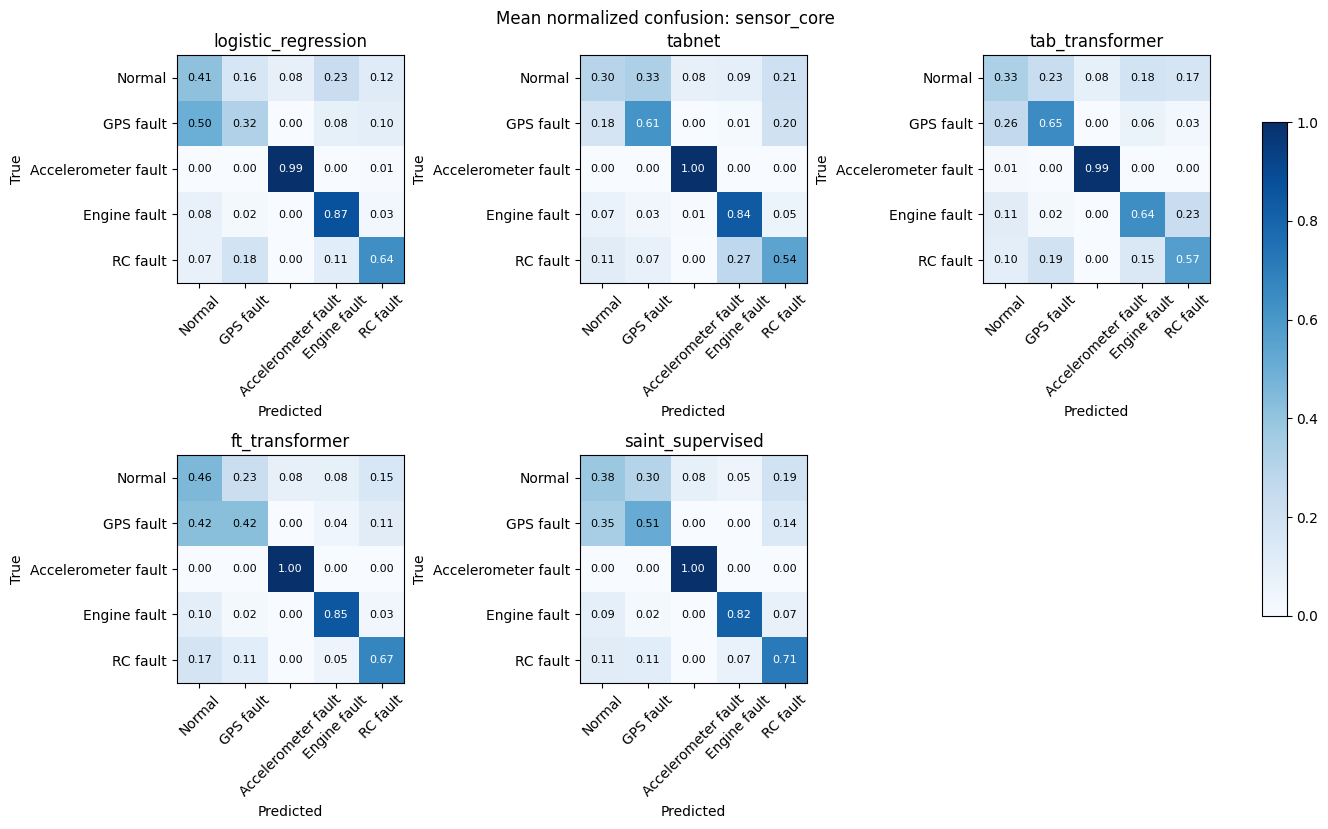

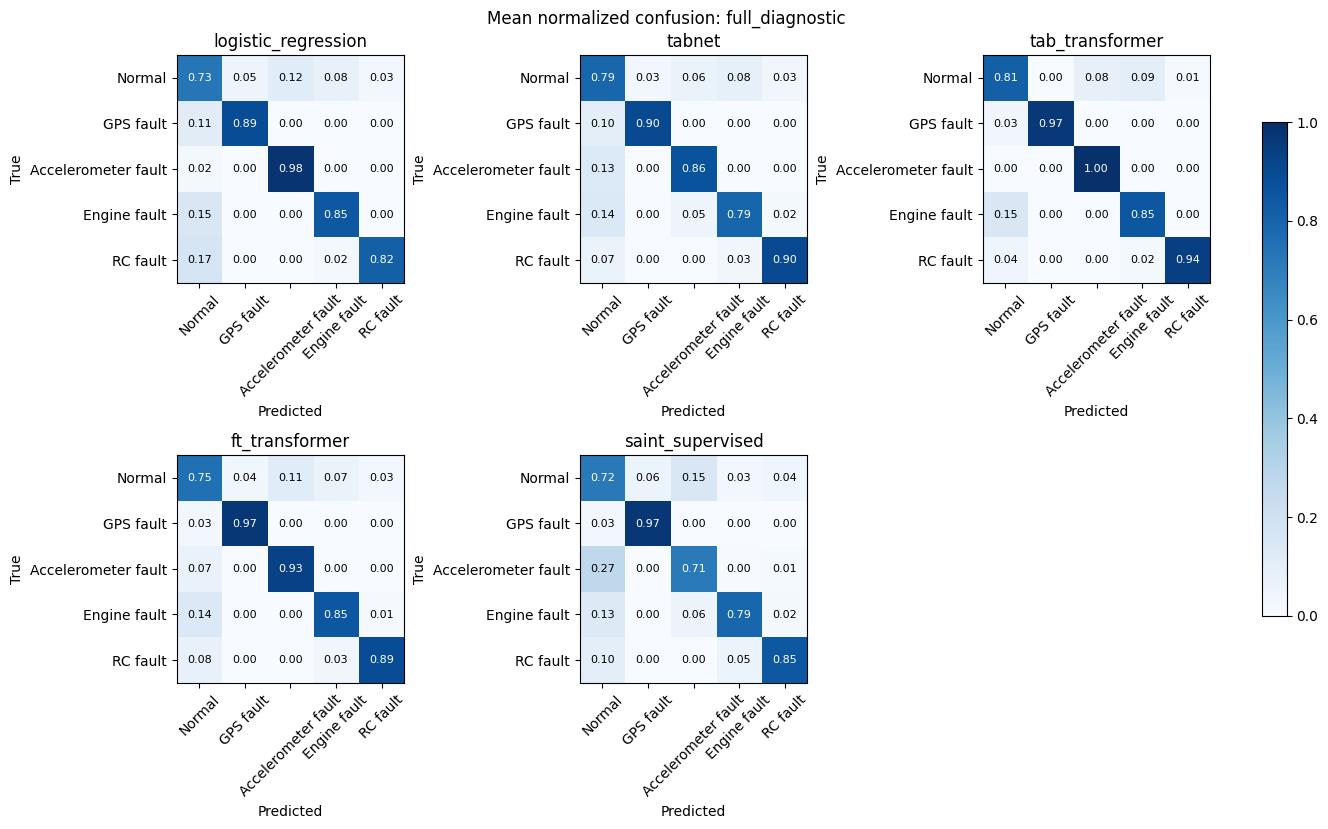

,view_name,model_name,class_name,mean,min
0,full_diagnostic,ft_transformer,Accelerometer fault,0.9329,0.5976
1,full_diagnostic,ft_transformer,Engine fault,0.8495,0.6936
2,full_diagnostic,ft_transformer,GPS fault,0.9709,0.9452
3,full_diagnostic,ft_transformer,Normal,0.7528,0.5089
4,full_diagnostic,ft_transformer,RC fault,0.8884,0.7742
5,full_diagnostic,logistic_regression,Accelerometer fault,0.9817,0.9736
6,full_diagnostic,logistic_regression,Engine fault,0.8472,0.6965
7,full_diagnostic,logistic_regression,GPS fault,0.8868,0.7769
8,full_diagnostic,logistic_regression,Normal,0.7299,0.5569
9,full_diagnostic,logistic_regression,RC fault,0.8153,0.7238


In [7]:
figure_dir = config.output_dir / "figures"
plot_flightwise_metric(
    results,
    output_path=figure_dir / "flightwise_f1_macro.png",
)
for view_name in config.feature_views:
    plot_mean_confusion_matrices(
        results,
        aligned.class_names,
        view_name=view_name,
        output_path=figure_dir / f"{view_name}_confusions.png",
    )
plt.show()

class_summary = (
    per_class_frame(results)
    .query("region == 'all_external_rows'")
    .groupby(["view_name", "model_name", "class_name"])["recall"]
    .agg(["mean", "min"])
    .reset_index()
)
display(class_summary.round(4))

## 8. Lectura correcta

Un modelo solo es convincente aquí si mantiene F1 macro y recall por clase en ambos vuelos, no solo en la media. Una mejora de `full_diagnostic` acompañada de una caída en `sensor_core` sugiere dependencia de contexto, aunque no identifica por sí sola una variable culpable.

Incluso el perfil `study` sigue siendo exploratorio: dos direcciones LOFO reutilizan los mismos dos vuelos y tres semillas miden estabilidad de optimización, no variabilidad poblacional. Ningún ranking de este cuaderno demuestra superioridad universal ni generalización a otros UAV.